# Modeling

This notebook contains the model training code.

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, cohen_kappa_score,
    matthews_corrcoef, roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC

from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours, RepeatedEditedNearestNeighbours
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

from collections import Counter
import os
from datetime import datetime
import json
from joblib import dump, load

In [2]:
FEATURE_COUNT = 3473

In [3]:
# Load dataset, using float32 dtype for float columns
dtypes = {f'f{i}': np.float32 for i in range(FEATURE_COUNT)}

int_colums = ['cell_number']
for c in int_colums:
    dtypes[c] = np.int64

object_columns = ['label', 'image_path', 'cell_image_path']
for c in object_columns:
    dtypes[c] = object

train_df = pd.read_csv('data/final_data/train_data_with_features.csv', dtype=dtypes)
val_df = pd.read_csv('data/final_data/val_data_with_features.csv', dtype=dtypes)

In [4]:
train_df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f3467,f3468,f3469,f3470,f3471,f3472,label,image_path,cell_number,cell_image_path
0,0.002533,0.025067,0.007200,0.087733,0.114267,0.360533,0.070933,0.053333,0.233733,0.044667,...,91.806000,12.529564,-0.218953,201.730927,9.080140,-1.050871,no_object,data/final_data/resized_images/299784.webp,58,data/final_data/grid_cells/299784/c58.jpg
1,0.003333,0.022933,0.015200,0.123200,0.386933,0.302400,0.054000,0.026400,0.041467,0.024133,...,68.478798,43.146996,1.002107,85.109467,30.384699,0.210047,no_object,data/final_data/resized_images/648ff941aa8f.webp,42,data/final_data/grid_cells/648ff941aa8f/c42.jpg
2,0.000933,0.011333,0.008133,0.106133,0.301200,0.320933,0.041200,0.033733,0.162267,0.014133,...,136.542267,71.812653,0.147966,197.526932,6.737097,-0.371850,no_object,data/final_data/resized_images/409575.webp,39,data/final_data/grid_cells/409575/c39.jpg
3,0.001867,0.016533,0.004933,0.082667,0.303600,0.398533,0.033467,0.021600,0.108133,0.028667,...,57.380001,12.993029,-1.470382,173.228531,61.692570,-0.751049,no_object,data/final_data/resized_images/408828.jpeg,55,data/final_data/grid_cells/408828/c55.jpg
4,0.000533,0.007600,0.001067,0.081067,0.014133,0.282400,0.034933,0.058800,0.508400,0.011067,...,193.431198,4.218049,0.029969,106.227730,1.987395,-0.120476,no_object,data/final_data/resized_images/306975.webp,4,data/final_data/grid_cells/306975/c04.jpg


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14335 entries, 0 to 14334
Columns: 3477 entries, f0 to cell_image_path
dtypes: float32(3473), int64(1), object(3)
memory usage: 190.4+ MB


In [6]:
train_df.columns

Index(['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9',
       ...
       'f3467', 'f3468', 'f3469', 'f3470', 'f3471', 'f3472', 'label',
       'image_path', 'cell_number', 'cell_image_path'],
      dtype='object', length=3477)

In [7]:
train_df['label'].value_counts()

label
no_object    12830
bat            656
stump          618
ball           231
Name: count, dtype: int64

In [8]:
# Convert labels to numerical values
label_mapping = {'no_object': 0, 'ball': 1, 'bat': 2, 'stump': 3}
train_df['label'] = train_df['label'].map(label_mapping)
val_df['label'] = val_df['label'].map(label_mapping)

In [9]:
val_df['label'].value_counts()

label
0    2750
2     140
3     133
1      50
Name: count, dtype: int64

In [10]:
feature_cols = [f'f{i}' for i in range(FEATURE_COUNT)]
target_column = 'label'

In [11]:
X_train = train_df[feature_cols]
y_train = train_df[target_column]
X_val = val_df[feature_cols]
y_val = val_df[target_column]

In [12]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((14335, 3473), (14335,), (3073, 3473), (3073,))

In [13]:
# Standardize the features before PCA
pre_scaler = StandardScaler()
X_train_scaled = pre_scaler.fit_transform(X_train)

X_val_scaled = pre_scaler.transform(X_val)

In [14]:
Counter(y_train)

Counter({0: 12830, 2: 656, 3: 618, 1: 231})

In [15]:

undersampler = RepeatedEditedNearestNeighbours(sampling_strategy='majority', max_iter=100)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train_scaled, y_train)

#X_train_resampled, y_train_resampled = X_train_scaled, y_train
sampling_strategy_dict = {
        0: 900,
        1: Counter(y_train_resampled)[1],
        2: Counter(y_train_resampled)[2],
        3: Counter(y_train_resampled)[3],
    }

undersampler = RandomUnderSampler(sampling_strategy=sampling_strategy_dict)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train_resampled, y_train_resampled)

Counter(y_train_resampled)

Counter({0: 900, 2: 656, 3: 618, 1: 231})

In [16]:
X_train_scaled, y_train = X_train_resampled, y_train_resampled

In [17]:
# Determine optimal number of components by explained variance
# Fit PCA with all components to analyze variance
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different variance thresholds
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Number of components explaining 90% variance: {n_components_90}")
print(f"Number of components explaining 95% variance: {n_components_95}")
print(f"Number of components explaining 99% variance: {n_components_99}")
print(f"\nTotal original components: {len(feature_cols)}")

Number of components explaining 90% variance: 575
Number of components explaining 95% variance: 783
Number of components explaining 99% variance: 1267

Total original components: 3473


In [18]:
# Apply PCA with 95% variance retention
n_components = n_components_90
pca = PCA(n_components=n_components)
X_train_scaled_pca = pca.fit_transform(X_train_scaled)

print(f"Original shape: {X_train_scaled.shape}")
print(f"Reduced shape: {X_train_scaled_pca.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Dimensionality reduction: {(1 - X_train_scaled_pca.shape[1]/X_train_scaled.shape[1])*100:.2f}%")

Original shape: (2405, 3473)
Reduced shape: (2405, 575)
Variance explained: 0.8983
Dimensionality reduction: 83.44%


In [19]:
# Apply same PCA transformation to test set
X_val_scaled_pca = pca.transform(X_val_scaled)
X_train_scaled_pca.shape, X_val_scaled_pca.shape

((2405, 575), (3073, 575))

In [20]:
# Now scale the PCA-transformed data using StandardScaler
post_scaler = StandardScaler()
X_train_final = post_scaler.fit_transform(X_train_scaled_pca)
X_val_final = post_scaler.transform(X_val_scaled_pca)
X_train_final.shape, X_val_final.shape  

((2405, 575), (3073, 575))

In [21]:
X_train_final[:5]

array([[-1.2803582 , -0.8985838 ,  0.28299236, ..., -1.8659809 ,
        -0.78295743, -0.6760155 ],
       [-0.42670164,  0.17277451, -0.216392  , ...,  2.0319831 ,
         0.44523227,  1.5308328 ],
       [-0.3031221 ,  0.16760148,  1.0149348 , ..., -0.12564379,
        -3.514498  , -1.2567756 ],
       [ 0.8680988 ,  0.43368298, -0.253763  , ...,  1.141425  ,
         0.5704456 ,  0.03691672],
       [ 0.8211708 ,  0.360776  , -1.4093473 , ...,  0.9173565 ,
         0.45633587,  0.5272393 ]], shape=(5, 575), dtype=float32)

In [22]:
def train_svm_rbf(X_train, y_train, C=1.0, gamma='scale'):
    """
    Train a Support Vector Machine classifier with RBF kernel.
    
    Parameters:
    -----------
    X_train : array-like
        Training features
    y_train : array-like
        Training labels
    C : float, default=1.0
        Regularization parameter. The strength of the regularization is inversely
        proportional to C. Must be strictly positive.
    gamma : {'scale', 'auto'} or float, default='scale'
        Kernel coefficient for 'rbf'.
        - if 'scale' (default): 1 / (n_features * X.var())
        - if 'auto': 1 / n_features
        - if float: uses the specified value
    
    Returns:
    --------
    model : SVC
        Trained SVM classifier
    """
    model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    return model

In [23]:
def print_model_performance_report(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Print comprehensive performance metrics for a classification model and save to files.
    
    Parameters:
    -----------
    model : sklearn classifier
        Trained classification model
    X_train : array-like
        Training features
    y_train : array-like
        Training labels
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    model_name : str, default="Model"
        Name of the model for display purposes
    """
    folder_path = os.path.join("metrics_and_reports", model_name)
    os.makedirs(folder_path, exist_ok=True)
    
    print("="*80)
    print(f"{model_name.upper()} PERFORMANCE REPORT")
    print("="*80)
    print(f"\nSaving reports to: {folder_path}")
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Get unique classes
    classes = np.unique(np.concatenate([y_train, y_test]))
    is_binary = len(classes) == 2
    
    # ========== OVERALL METRICS ==========
    print("\n" + "="*80)
    print("OVERALL METRICS")
    print("="*80)
    
    metrics_data = []
    
    # Calculate metrics for train and test
    for dataset_name, y_true, y_pred in [("TRAIN", y_train, y_train_pred), 
                                          ("TEST", y_test, y_test_pred)]:
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        f1 = f1_score(y_true, y_pred, average='macro')
        kappa = cohen_kappa_score(y_true, y_pred)
        mcc = matthews_corrcoef(y_true, y_pred)
        
        metrics_data.append({
            'Dataset': dataset_name,
            'Accuracy': accuracy,
            'Precision (Weighted)': precision,
            'Recall (Weighted)': recall,
            'F1-Score (Weighted)': f1,
            'Cohen\'s Kappa': kappa,
            'Matthews Corr Coef': mcc
        })
    
    # Display metrics in table format
    metrics_df = pd.DataFrame(metrics_data)
    print("\n" + metrics_df.to_string(index=False))
    
    # Save metrics to CSV
    metrics_csv_path = os.path.join(folder_path, "overall_metrics.csv")
    metrics_df.to_csv(metrics_csv_path, index=False)
    print(f"\n✓ Overall metrics saved to: {metrics_csv_path}")
    
    # ========== CLASS-WISE METRICS ==========
    print("\n\n" + "="*80)
    print("CLASS-WISE PERFORMANCE - TRAINING SET")
    print("="*80)
    train_report = classification_report(y_train, y_train_pred)
    print(train_report)
    
    print("\n" + "="*80)
    print("CLASS-WISE PERFORMANCE - TEST SET")
    print("="*80)
    test_report = classification_report(y_test, y_test_pred)
    print(test_report)
    
    # ========== CONFUSION MATRICES ==========
    print("\n" + "="*80)
    print("CONFUSION MATRICES")
    print("="*80)
    
    # Calculate confusion matrices
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)
    
    # Plot confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Training confusion matrix
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_title(f'{model_name} - Training Set Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    
    # Test confusion matrix
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=classes, yticklabels=classes, ax=axes[1])
    axes[1].set_title(f'{model_name} - Test Set Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    
    # Save confusion matrix plot
    cm_plot_path = os.path.join(folder_path, "confusion_matrices.png")
    plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Confusion matrix plot saved to: {cm_plot_path}")
    
    plt.show()
    
    # Print confusion matrices in text format as well
    print("\nTraining Set Confusion Matrix:")
    print(cm_train)
    print("\nTest Set Confusion Matrix:")
    print(cm_test)
    
    # ========== ADDITIONAL INSIGHTS ==========
    print("\n" + "="*80)
    print("ADDITIONAL INSIGHTS")
    print("="*80)
    
    train_samples = len(y_train)
    test_samples = len(y_test)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    print(f"\nDataset Sizes:")
    print(f"  - Training samples: {train_samples}")
    print(f"  - Test samples: {test_samples}")
    print(f"  - Total samples: {train_samples + test_samples}")
    
    print(f"\nClass Distribution:")
    print(f"  Training set:")
    train_dist = pd.Series(y_train).value_counts().sort_index()
    for cls, count in train_dist.items():
        print(f"    Class {cls}: {count} ({count/len(y_train)*100:.2f}%)")
    
    print(f"\n  Test set:")
    test_dist = pd.Series(y_test).value_counts().sort_index()
    for cls, count in test_dist.items():
        print(f"    Class {cls}: {count} ({count/len(y_test)*100:.2f}%)")
    
    # Overfitting check
    accuracy_diff = train_accuracy - test_accuracy
    print(f"\nOverfitting Analysis:")
    print(f"  - Training Accuracy: {train_accuracy:.4f}")
    print(f"  - Test Accuracy: {test_accuracy:.4f}")
    print(f"  - Difference: {accuracy_diff:.4f}")
    
    if accuracy_diff > 0.10:
        overfitting_status = "⚠️  WARNING: Significant overfitting detected (difference > 10%)"
    elif accuracy_diff > 0.05:
        overfitting_status = "⚠️  CAUTION: Moderate overfitting detected (difference > 5%)"
    else:
        overfitting_status = "✓  Model generalization appears good"
    
    print(f"  {overfitting_status}")
    
    # ========== SAVE DETAILED REPORT TO TEXT FILE ==========
    report_txt_path = os.path.join(folder_path, "detailed_report.txt")
    with open(report_txt_path, 'w') as f:
        # Model Hyperparameters
        f.write("="*80 + "\n")
        f.write(f"{model_name.upper()} Hyper-parameters\n")
        f.write(f"{model.get_params()}")
        f.write("="*80 + "\n\n")

        f.write("="*80 + "\n")
        f.write(f"{model_name.upper()} PERFORMANCE REPORT\n")
        f.write("="*80 + "\n\n")
        
        f.write("CLASS-WISE PERFORMANCE - TRAINING SET\n")
        f.write("="*80 + "\n")
        f.write(train_report + "\n\n")
        
        f.write("CLASS-WISE PERFORMANCE - TEST SET\n")
        f.write("="*80 + "\n")
        f.write(test_report + "\n\n")
        
        f.write("CONFUSION MATRICES\n")
        f.write("="*80 + "\n")
        f.write("\nTraining Set Confusion Matrix:\n")
        f.write(str(cm_train) + "\n\n")
        f.write("Test Set Confusion Matrix:\n")
        f.write(str(cm_test) + "\n\n")
        
        f.write("ADDITIONAL INSIGHTS\n")
        f.write("="*80 + "\n")
        f.write(f"\nDataset Sizes:\n")
        f.write(f"  - Training samples: {train_samples}\n")
        f.write(f"  - Test samples: {test_samples}\n")
        f.write(f"  - Total samples: {train_samples + test_samples}\n\n")
        
        f.write(f"Class Distribution:\n")
        f.write(f"  Training set:\n")
        for cls, count in train_dist.items():
            f.write(f"    Class {cls}: {count} ({count/len(y_train)*100:.2f}%)\n")
        
        f.write(f"\n  Test set:\n")
        for cls, count in test_dist.items():
            f.write(f"    Class {cls}: {count} ({count/len(y_test)*100:.2f}%)\n")
        
        f.write(f"\nOverfitting Analysis:\n")
        f.write(f"  - Training Accuracy: {train_accuracy:.4f}\n")
        f.write(f"  - Test Accuracy: {test_accuracy:.4f}\n")
        f.write(f"  - Difference: {accuracy_diff:.4f}\n")
        f.write(f"  {overfitting_status}\n")
    
    print(f"\n✓ Detailed report saved to: {report_txt_path}")

    # Save hyperparameters to json file
    hyper_params = model.get_params()
    with open(os.path.join(folder_path, "hyperparams.json"), "w") as fp:
        json.dump(hyper_params, fp, indent=4)
    
    
    print("\n" + "="*80)
    print("END OF REPORT")
    print("="*80)

In [24]:
def hyperparameter_search_svm(X_train, y_train, X_test, y_test, n_trials=20):
    """
    Perform hyperparameter search on SVM with RBF kernel.
    
    Parameters:
    -----------
    X_train : array-like
        Training features
    y_train : array-like
        Training labels
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    n_trials : int, default=20
        Maximum number of trials to run
        
    Returns:
    --------
    leaderboard_df : DataFrame
        Top 5 models ranked by F1-score with their hyperparameters and metrics
    """
    from itertools import product
    
    # Define hyperparameter search space
    # C values: regularization parameter (common to less common)
    C_values = [1.0, 10.0, 100.0, 0.01, 50.0, 200.0, 500.0]
    #C_values = [1.0]
    
    # gamma values: kernel coefficient (common to less common)
    gamma_values = ['scale', 'auto', 0.001, 0.01, 0.1, 1.0, 0.0001, 10.0]
    #gamma_values = ['scale']
    
    # Generate all combinations
    all_combinations = list(product(C_values, gamma_values))
    
    # Limit to n_trials
    if len(all_combinations) > n_trials:
        # Take the most common combinations first
        combinations_to_try = all_combinations[:n_trials]
    else:
        combinations_to_try = all_combinations
    
    print(f"Starting hyperparameter search with {len(combinations_to_try)} trials...")
    print("="*80)
    
    results = []
    
    for trial_num, (C, gamma) in enumerate(combinations_to_try, 1):
        print(f"\nTrial {trial_num}/{len(combinations_to_try)}: C={C}, gamma={gamma}")
        
        try:
            # Train model
            model = train_svm_rbf(X_train, y_train, C=C, gamma=gamma)
            
            # Make predictions
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)
            
            # Calculate metrics
            train_accuracy = accuracy_score(y_train, y_train_pred)
            test_accuracy = accuracy_score(y_test, y_test_pred)
            train_f1 = f1_score(y_train, y_train_pred, average='macro')
            test_f1 = f1_score(y_test, y_test_pred, average='macro')
            train_precision = precision_score(y_train, y_train_pred, average='macro')
            test_precision = precision_score(y_test, y_test_pred, average='macro')
            train_recall = recall_score(y_train, y_train_pred, average='macro')
            test_recall = recall_score(y_test, y_test_pred, average='macro')
            
            # Store results
            results.append({
                'trial': trial_num,
                'C': C,
                'gamma': gamma,
                'train_accuracy': train_accuracy,
                'test_accuracy': test_accuracy,
                'train_f1': train_f1,
                'test_f1': test_f1,
                'train_precision': train_precision,
                'test_precision': test_precision,
                'train_recall': train_recall,
                'test_recall': test_recall,
                'overfitting_gap': train_accuracy - test_accuracy
            })
            
            print(f"  ✓ Test F1-Score: {test_f1:.4f}, Test Accuracy: {test_accuracy:.4f}")
            
        except Exception as e:
            print(f"  ✗ Failed: {str(e)}")
            continue
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Sort by test F1-score (descending) and get top 10
    leaderboard_df = results_df.sort_values('test_f1', ascending=False).head(10).reset_index(drop=True)
    leaderboard_df.index = leaderboard_df.index + 1  # Start ranking from 1
    
    print("\n" + "="*80)
    print("HYPERPARAMETER SEARCH COMPLETE")
    print("="*80)
    print(f"\nTotal trials completed: {len(results)}")
    print(f"\nTOP 5 MODELS BY F1-SCORE:")
    print("="*80)
    
    # Display leaderboard
    display_columns = ['trial', 'C', 'gamma', 'test_f1', 'test_accuracy', 
                       'test_precision', 'test_recall', 'overfitting_gap']
    print(leaderboard_df[display_columns].to_string())
    
    print("\n" + "="*80)
    
    return leaderboard_df

In [25]:
# Example usage: Run hyperparameter search with 20 trials
leaderboard = hyperparameter_search_svm(X_train_final, y_train, X_val_final, y_val, n_trials=20)

Starting hyperparameter search with 20 trials...

Trial 1/20: C=1.0, gamma=scale
  ✓ Test F1-Score: 0.3834, Test Accuracy: 0.6538

Trial 2/20: C=1.0, gamma=auto
  ✓ Test F1-Score: 0.3834, Test Accuracy: 0.6538

Trial 3/20: C=1.0, gamma=0.001
  ✓ Test F1-Score: 0.3886, Test Accuracy: 0.6476

Trial 4/20: C=1.0, gamma=0.01


/home/rahul/ePGD-AIML/PML Project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  ✓ Test F1-Score: 0.0705, Test Accuracy: 0.0905

Trial 5/20: C=1.0, gamma=0.1


/home/rahul/ePGD-AIML/PML Project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  ✓ Test F1-Score: 0.0211, Test Accuracy: 0.0439

Trial 6/20: C=1.0, gamma=1.0


...

/home/rahul/ePGD-AIML/PML Project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  ✓ Test F1-Score: 0.2361, Test Accuracy: 0.8949

Trial 15/20: C=10.0, gamma=0.0001
  ✓ Test F1-Score: 0.3791, Test Accuracy: 0.6411

Trial 16/20: C=10.0, gamma=10.0


/home/rahul/ePGD-AIML/PML Project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  ✓ Test F1-Score: 0.2361, Test Accuracy: 0.8949

Trial 17/20: C=100.0, gamma=scale
  ✓ Test F1-Score: 0.4231, Test Accuracy: 0.7439

Trial 18/20: C=100.0, gamma=auto
  ✓ Test F1-Score: 0.4231, Test Accuracy: 0.7439

Trial 19/20: C=100.0, gamma=0.001
  ✓ Test F1-Score: 0.4092, Test Accuracy: 0.7260

Trial 20/20: C=100.0, gamma=0.01
  ✓ Test F1-Score: 0.2361, Test Accuracy: 0.8949

HYPERPARAMETER SEARCH COMPLETE

Total trials completed: 20

TOP 5 MODELS BY F1-SCORE:
    trial      C   gamma   test_f1  test_accuracy  test_precision  test_recall  overfitting_gap
1      18  100.0    auto  0.423105       0.743898        0.411652     0.564420         0.256102
2      17  100.0   scale  0.423105       0.743898        0.411652     0.564420         0.256102
3       9   10.0   scale  0.423105       0.743898        0.411652     0.564420         0.256102
4      10   10.0    auto  0.423105       0.743898        0.411652     0.564420         0.256102
5      19  100.0   0.001  0.409239       0.726001 

/home/rahul/ePGD-AIML/PML Project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [26]:
# Display the leaderboard
leaderboard

,trial,C,gamma,train_accuracy,test_accuracy,train_f1,test_f1,train_precision,test_precision,train_recall,test_recall,overfitting_gap
1,18,100.0,auto,1.000000,0.743898,1.000000,0.423105,1.000000,0.411652,1.000000,0.564420,0.256102
2,17,100.0,scale,1.000000,0.743898,1.000000,0.423105,1.000000,0.411652,1.000000,0.564420,0.256102
3,9,10.0,scale,1.000000,0.743898,1.000000,0.423105,1.000000,0.411652,1.000000,0.564420,0.256102
4,10,10.0,auto,1.000000,0.743898,1.000000,0.423105,1.000000,0.411652,1.000000,0.564420,0.256102
5,19,100.0,0.001,1.000000,0.726001,1.000000,0.409239,1.000000,0.381656,1.000000,0.564154,0.273999
6,11,10.0,0.001,1.000000,0.725675,1.000000,0.408579,1.000000,0.381171,1.000000,0.562368,0.274325
7,3,1.0,0.001,0.942620,0.647576,0.950763,0.388560,0.949203,0.372779,0.953752,0.592131,0.295044
8,1,1.0,scale,0.985863,0.653759,0.988428,0.383420,0.987795,0.394369,0.989119,0.557693,0.332104
9,2,1.0,auto,0.985863,0.653759,0.988428,0.383420,0.987795,0.394369,0.989119,0.557693,0.332104
10,15,10.0,0.0001,0.859875,0.641067,0.853445,0.379147,0.838349,0.366965,0.879839,0.569424,0.218808


In [27]:
# Train the best model from the leaderboard
best_params = leaderboard.iloc[0]
best_model = train_svm_rbf(
    X_train_final, 
    y_train, 
    C=best_params['C'], 
    gamma=best_params['gamma']
)

timestamp = datetime.now().strftime("%m%d_%H%M%S")
model_prefix = 'SVM'
model_name = f"{model_prefix}_{timestamp}"

print(f"\nBest hyperparameters:")
print(f"  C: {best_params['C']}")
print(f"  gamma: {best_params['gamma']}")
print(f"  Test F1-Score: {best_params['test_f1']:.4f}")


Best hyperparameters:
  C: 100.0
  gamma: auto
  Test F1-Score: 0.4231


SVM_1213_232905 PERFORMANCE REPORT

Saving reports to: metrics_and_reports/SVM_1213_232905

OVERALL METRICS

Dataset  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)  Cohen's Kappa  Matthews Corr Coef
  TRAIN  1.000000              1.000000            1.00000             1.000000       1.000000            1.000000
   TEST  0.743898              0.411652            0.56442             0.423105       0.283851            0.339435

✓ Overall metrics saved to: metrics_and_reports/SVM_1213_232905/overall_metrics.csv


CLASS-WISE PERFORMANCE - TRAINING SET
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       900
           1       1.00      1.00      1.00       231
           2       1.00      1.00      1.00       656
           3       1.00      1.00      1.00       618

    accuracy                           1.00      2405
   macro avg       1.00      1.00      1.00      2405
weighted avg       1.00      1.00      1.

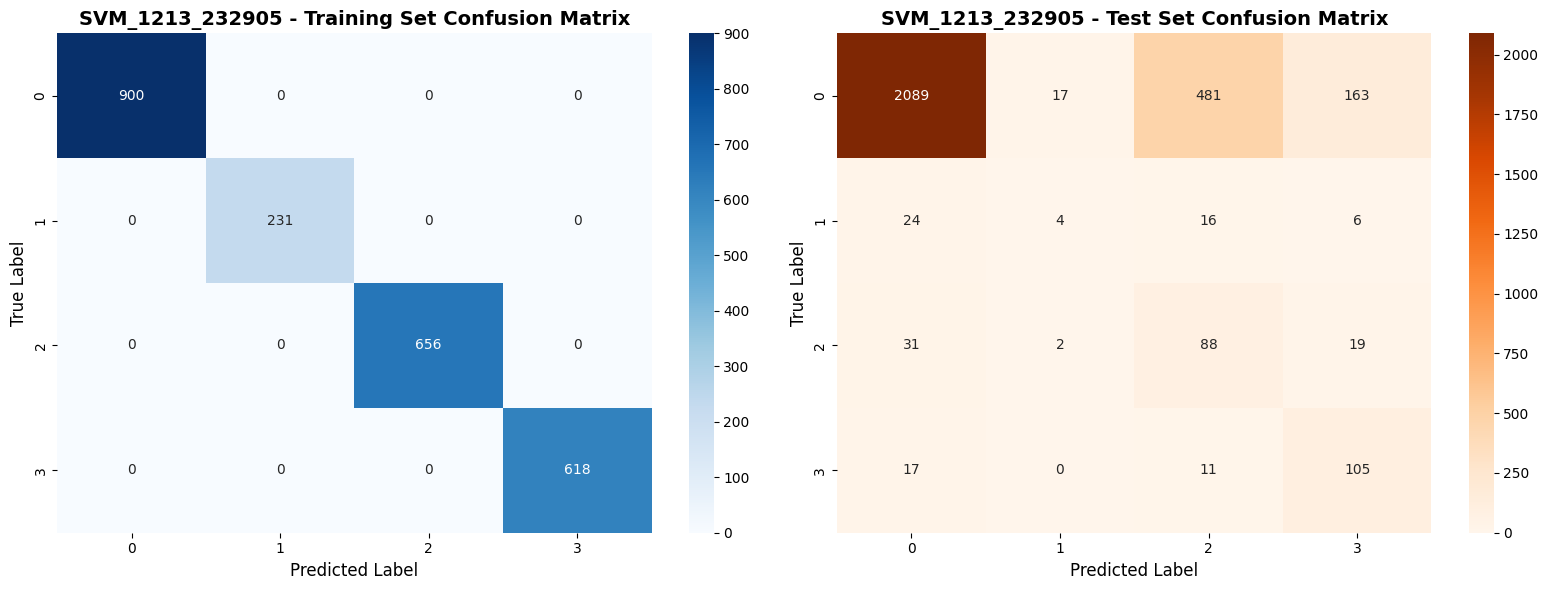


Training Set Confusion Matrix:
[[900   0   0   0]
 [  0 231   0   0]
 [  0   0 656   0]
 [  0   0   0 618]]

Test Set Confusion Matrix:
[[2089   17  481  163]
 [  24    4   16    6]
 [  31    2   88   19]
 [  17    0   11  105]]

ADDITIONAL INSIGHTS

Dataset Sizes:
  - Training samples: 2405
  - Test samples: 3073
  - Total samples: 5478

Class Distribution:
  Training set:
    Class 0: 900 (37.42%)
    Class 1: 231 (9.60%)
    Class 2: 656 (27.28%)
    Class 3: 618 (25.70%)

  Test set:
    Class 0: 2750 (89.49%)
    Class 1: 50 (1.63%)
    Class 2: 140 (4.56%)
    Class 3: 133 (4.33%)

Overfitting Analysis:
  - Training Accuracy: 1.0000
  - Test Accuracy: 0.7439
  - Difference: 0.2561
  ⚠️  WARNING: Significant overfitting detected (difference > 10%)

✓ Detailed report saved to: metrics_and_reports/SVM_1213_232905/detailed_report.txt

END OF REPORT


In [28]:
# Evaluate the best model

print_model_performance_report(best_model, X_train_final, y_train, X_val_final, y_val, model_name=model_name)

In [30]:
# save the model
with open(f"metrics_and_reports/{model_name}/{model_name}.pkl", "wb") as f:
    dump(best_model, f, protocol=5)

# save the pre and post scalers and PCA
with open(f"metrics_and_reports/{model_name}/pre_scaler.pkl", "wb") as f:
    dump(pre_scaler, f, protocol=5)

with open(f"metrics_and_reports/{model_name}/post_scaler.pkl", "wb") as f:
    dump(post_scaler, f, protocol=5)

with open(f"metrics_and_reports/{model_name}/pca.pkl", "wb") as f:
    dump(pca, f, protocol=5)


In [31]:
# Save the best model along with metrics to the folder 'final_model'. 
import shutil

model_src_folder = os.path.join("metrics_and_reports", model_name)
final_model_folder = "final_model"
os.makedirs(final_model_folder, exist_ok=True)
shutil.copytree(model_src_folder, final_model_folder, dirs_exist_ok=True)

'final_model'